In [4]:
import os
from pathlib import Path
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
    sys.path.insert(0, os.getcwd())

PROJECT_ROOT = Path.cwd()

In [5]:
DATA_DIR = PROJECT_ROOT / "data"
BEATMAPS_DIR = DATA_DIR / "beatmaps"
COLLECTIONS_DIR = DATA_DIR / "collections"

RATINGS_PATH = DATA_DIR / "ratings.parquet"
BEATMAPS_PATH = BEATMAPS_DIR / "beatmaps.parquet"
COLLECTIONS_PATH = COLLECTIONS_DIR / "collections.parquet"

Loaded 97,236 beatmaps (< 14 stars)

STAR RATING STATISTICS
Mean:    5.42
Median:  5.51
Std Dev: 1.82
Range:   0.14 - 13.96

DISTRIBUTION
0-1     :     120 (  0.1%)
1-2     :   3,274 (  3.4%)
2-3     :   8,537 (  8.8%)
3-4     :   9,404 (  9.7%)
4-5     :  14,619 ( 15.0%)
5-6     :  24,534 ( 25.2%)
6-7     :  18,882 ( 19.4%)
7-8     :  10,906 ( 11.2%)
8-9     :   4,721 (  4.9%)
9-10    :   1,698 (  1.7%)
10-11   :     383 (  0.4%)
11-12   :     100 (  0.1%)
12-13   :      41 (  0.0%)
13-14   :      17 (  0.0%)


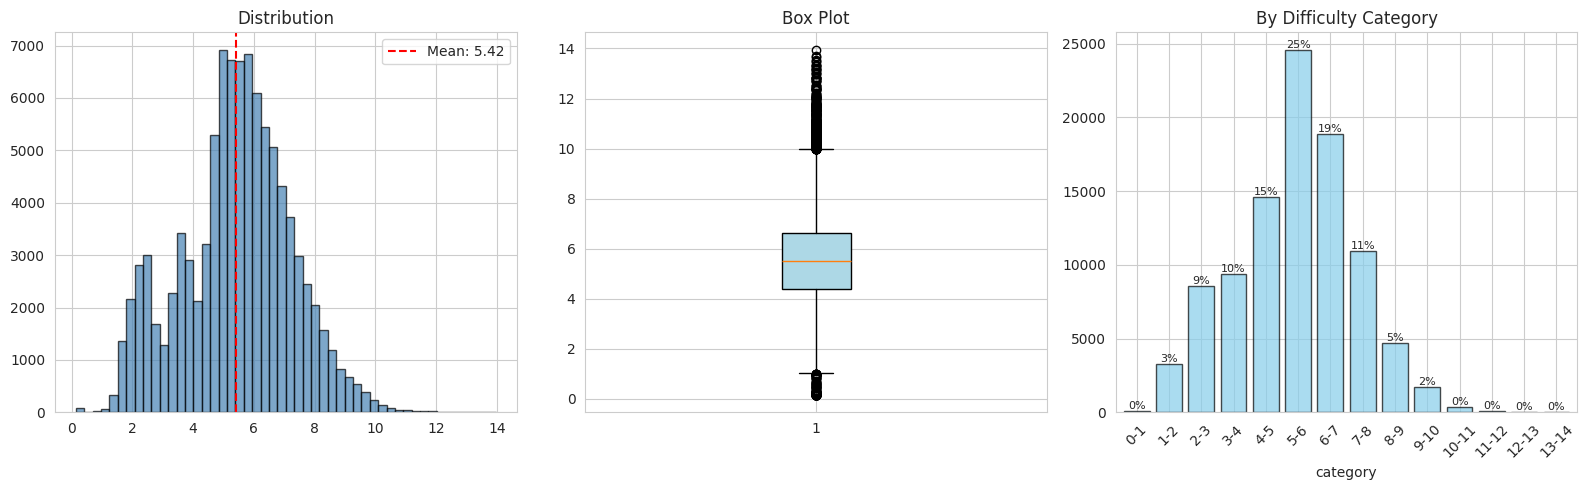

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

ratings_df = pd.read_parquet(RATINGS_PATH)

star_df = ratings_df[['beatmap_id', 'stars']].copy()
star_df = star_df[star_df['stars'] < 14]

print(f"Loaded {len(star_df):,} beatmaps (< 14 stars)")

stats = star_df['stars'].describe()
print("\nSTAR RATING STATISTICS")
print(f"Mean:    {stats['mean']:.2f}")
print(f"Median:  {stats['50%']:.2f}")
print(f"Std Dev: {stats['std']:.2f}")
print(f"Range:   {stats['min']:.2f} - {stats['max']:.2f}")

bins = range(0, 15)
labels = [f"{i}-{i+1}" for i in range(0, 14)]
star_df['category'] = pd.cut(star_df['stars'], bins=bins, labels=labels, right=False)
cat_counts = star_df['category'].value_counts().sort_index()

print("\nDISTRIBUTION")
for label, count in cat_counts.items():
    pct = count / len(star_df) * 100
    print(f"{label:8}: {count:7,} ({pct:5.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(star_df['stars'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(stats['mean'], color='red', linestyle='--', label=f"Mean: {stats['mean']:.2f}")
axes[0].set_title('Distribution')
axes[0].legend()

axes[1].boxplot(star_df['stars'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Box Plot')

cat_counts.plot(kind='bar', ax=axes[2], color='skyblue', alpha=0.7, edgecolor='black', width=0.8)
axes[2].set_title('By Difficulty Category')
axes[2].tick_params(axis='x', rotation=45)

for i, v in enumerate(cat_counts):
    axes[2].text(i, v, f'{v/len(star_df)*100:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()